In [55]:
import pandas as pd 

In [56]:
df = pd.read_csv('cs-training.csv')

In [57]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [58]:
df = df.drop('Unnamed: 0', axis=1) # removes that useless column. axis=1 tells pandas "this is a column, not a row."

In [59]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [60]:
print(df.shape)

(150000, 11)


In [61]:
df['SeriousDlqin2yrs'].value_counts()
# counts how many people are 0 (no default) vs 1 (default) in our target column. This is the imbalance check we talked about.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [62]:
df.isnull().head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False


In [63]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [64]:
df.describe()
# From describe() — a few red flags already visible:

# RevolvingUtilizationOfUnsecuredLines — this is supposed to be a percentage/ratio (per the data dictionary), so it should mostly be
# between 0 and 1 (maybe slightly above for edge cases). But the max is 50,708 — that's clearly a data error, not a real value.
# age — min is 0. Nobody applying for credit is age 0. That's a bad/placeholder value.
# NumberOfTime30-59DaysPastDueNotWorse — max is 98. This dataset is known to sometimes use 96/98
# as a coded "placeholder" value rather than a real count — we'll need to confirm this.
# DebtRatio — also supposed to be a ratio, but max is 329,664. Same issue as RevolvingUtilization — clearly bad data.

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [65]:
print("Age = 0 count:", (df['age'] == 0).sum())
print("RevolvingUtilization > 1 count:", (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())
print("NumberOfTime30-59 = 96 or 98:", df['NumberOfTime30-59DaysPastDueNotWorse'].isin([96, 98]).sum())
print("NumberOfTimes90DaysLate = 96 or 98:", df['NumberOfTimes90DaysLate'].isin([96, 98]).sum())
print("NumberOfTime60-89 = 96 or 98:", df['NumberOfTime60-89DaysPastDueNotWorse'].isin([96, 98]).sum())

Age = 0 count: 1
RevolvingUtilization > 1 count: 3321
NumberOfTime30-59 = 96 or 98: 269
NumberOfTimes90DaysLate = 96 or 98: 269
NumberOfTime60-89 = 96 or 98: 269


In [66]:
# age = 0: only 1 row — trivial, easy fix.
# RevolvingUtilization > 1: 3,321 rows (~2.2% of data) — a real, non-trivial chunk. Since this is meant to be a ratio,
# values slightly above 1 could theoretically happen (someone over their credit limit), but values like 50,708 are clearly broken 
# data entries, not real people.
# The 96/98 placeholder values: exactly 269 rows in all three lateness columns. Notice all three counts are identical (269) —
# that's not a coincidence. This strongly suggests it's the same 269 rows where 96/98 was used as an error/placeholder 
# code across all three "days past due" columns together, rather than 269 different people each having a real value of 96 or 98
# late payments (which would be almost impossible in real life). I'm fairly confident this is a known data-quality quirk of this 
# specific dataset from having seen it discussed before, but I haven't independently re-verified that claim right now, 
# so treat it as a reasonable working assumption rather than a certainty — we can double check with one line of code.

In [67]:
same_rows = df[(df['NumberOfTime30-59DaysPastDueNotWorse'].isin([96,98])) &
               (df['NumberOfTimes90DaysLate'].isin([96,98])) &
               (df['NumberOfTime60-89DaysPastDueNotWorse'].isin([96,98]))]
print(len(same_rows))
# all 269 rows are the same broken records across all three columns

269


In [68]:
# 1. Drop the bad rows (age=0 and the 96/98 placeholder rows):

df = df[df['age'] != 0]
df = df[~df['NumberOfTime30-59DaysPastDueNotWorse'].isin([96, 98])]
print(df.shape)

# df['age'] != 0 — keeps only rows where age is NOT 0.
# ~df[...].isin([96, 98]) — the ~ means "NOT," so this keeps only rows where the value is NOT 96 or 98.
# Since we confirmed it's the same 269 rows across all three columns, filtering on just this one column removes all of them.
# df.shape — should now show roughly (149730, 11) — we removed 1 + 269 = 270 rows.

(149730, 11)


In [69]:
# Cap the extreme RevolvingUtilizationOfUnsecuredLines values instead of dropping them:
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.5)

# What this does: clip(upper=1.5) means "any value bigger than 1.5, just set it to 1.5 instead." We're choosing 1.5 (not exactly 1) 
# to allow a bit of real-world flexibility (someone slightly over their limit), while still killing off the absurd values like 50,708. 
# This is a judgment call, not a hard rule — 1.5 is a reasonable, defensible choice, but if you want, we can also try capping at exactly 
# 1.0 later and see if it changes model performance.

In [70]:
# 3. Handle the missing values (MonthlyIncome and NumberOfDependents):
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())
print(df.isnull().sum())

# fillna(median()) — replaces missing values with the median (middle value) of that column, not the mean, because income data is
# usually skewed by a few very high earners, and median is more robust to that.
# The final print(df.isnull().sum()) should now show 0 missing values everywhere — confirming the cleaning worked.

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [71]:
# I missed addressing it explicitly earlier: remember DebtRatio also had a suspicious max value (329,664), same issue as RevolvingUtilization
# Cap DebtRatio similarly:
df['DebtRatio'] = df['DebtRatio'].clip(upper=5)

In [72]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149730.000000,149730.000000,149730.000000,149730.000000,149730.000000,1.497300e+05,149730.000000,149730.000000,149730.000000,149730.000000,149730.000000
mean,0.065979,0.321708,52.327984,0.245789,1.288340,6.423097e+03,8.467949,0.090456,1.020063,0.064823,0.738142
std,0.248246,0.357796,14.754371,0.697779,1.884854,1.290112e+04,5.138107,0.485529,1.129961,0.330074,1.107373
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029771,41.000000,0.000000,0.175994,3.915000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153488,52.000000,0.000000,0.367119,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555592,63.000000,0.000000,0.870023,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.500000,109.000000,13.000000,5.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


In [73]:
# Great — cleaning is genuinely done now. 

# age min is now 21 (0 is gone) ✅
# RevolvingUtilizationOfUnsecuredLines max is now 1.5 (capped) ✅
# DebtRatio max is now 5 (capped) ✅
# NumberOfTime30-59DaysPastDueNotWorse max dropped from 98 to 13 — confirms those placeholder rows are gone ✅

# Step 4: Feature Engineering

In [74]:
# 1. Combine the three "late payment" columns into one total:
df['TotalTimesLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                         df['NumberOfTime60-89DaysPastDueNotWorse'] +
                         df['NumberOfTimes90DaysLate'])

# Why: instead of the model treating "mildly late twice" and "severely late twice" as unrelated signals, 
# this gives it one strong combined "how often has this person been late overall" feature — often one of the most 
# predictive features in credit-risk models.

In [75]:
# 2. Income per dependent (financial burden per family member):
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Why: +1 avoids dividing by zero for people with 0 dependents. This captures "how stretched is this person's income 
# across their household" —  different from raw income alone.

In [76]:
# 3. A simple flag: has this person ever been seriously (90+ days) late?
df['EverSeriouslyLate'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)

# Why: sometimes a simple yes/no flag captures a pattern more cleanly than a raw count, especially for tree-based models later.

In [77]:
df[['TotalTimesLate', 'IncomePerDependent', 'EverSeriouslyLate']].describe()

,TotalTimesLate,IncomePerDependent,EverSeriouslyLate
count,149730.000000,1.497300e+05,149730.000000
mean,0.401069,4.591296e+03,0.053890
std,1.102150,7.981037e+03,0.225802
min,0.000000,0.000000e+00,0.000000
25%,0.000000,2.155000e+03,0.000000
50%,0.000000,4.000000e+03,0.000000
75%,0.000000,5.400000e+03,0.000000
max,19.000000,1.794060e+06,1.000000


# Step 5: Spliting data and building first baseline model

In [78]:
# X = all your feature columns (everything except the target) — the "clues."
# y = just SeriousDlqin2yrs — the "answer" we're trying to predict.
# We split data into train (the model learns from this) and test (we hide this from the model, then check how well 
# it predicts on data it's never seen — this is how we honestly measure performance, not by testing on data it already memorized).

In [79]:
# 1. Separate features (X) and target (y):
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [80]:
# 2. Split into train and test sets:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(119784, 13) (29946, 13)


In [81]:
# test_size=0.2 — 80% of data for training, 20% held back for testing.
# random_state=42 — makes the split reproducible; if you rerun this, you get the exact same split every time (42 has no special meaning,
# it's just a common convention — any fixed number works the same way).
# stratify=y — this one matters a lot for us specifically. Since our data is imbalanced (93/7), a random split could accidentally put 
# too many or too few defaulters in the test set. 
# stratify=y forces both train and test sets to keep the same 93/7 ratio as the original data. 
# Without this, your evaluation later could be misleading.

# 3. first baseline model — Logistic Regression

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27970
           1       0.60      0.19      0.28      1976

    accuracy                           0.94     29946
   macro avg       0.77      0.59      0.63     29946
weighted avg       0.92      0.94      0.92     29946

ROC-AUC: 0.8398000442203113


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [83]:
# 1. The ConvergenceWarning — harmless, easy fix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# transforms every feature to have a similar scale (mean 0, similar spread) — so no single feature (like income) dominates
# just because its raw numbers are bigger. Note: fit_transform on train, but only transform (not fit) on test — this is important.
# We only "learn" the scaling from training data, then apply the same transformation to test data, to avoid leaking test information into training.

In [84]:
# 2. The actual results — this is the real story

# Look at class 1 (the defaulters — the ones we actually care about catching):

# Precision: 0.60, Recall: 0.19, F1: 0.28

# In plain English: your model only catches 19% of actual defaulters. Out of every 100 people who will actually default, 
# this model correctly flags only ~19 of them and misses ~81. Meanwhile, accuracy shows 0.94 (94%!) — looks great on the surface,
# but it's a misleading number here, because the model could get 94% accuracy just by predicting "no default" for almost everyone, 
# since 93% of the data is already "no default." This is exactly why we don't trust accuracy on imbalanced data 
# — this is the "before" picture I told you to expect.

# The ROC-AUC of 0.84 is a genuinely reasonable score, but the classification report shows the practical problem clearly: 
# as-is, this model would be nearly useless for actually catching risky borrowers, which is the entire point of the project.

model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = model_balanced.predict(X_test_scaled)
y_proba_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27970
           1       0.22      0.72      0.33      1976

    accuracy                           0.81     29946
   macro avg       0.60      0.77      0.61     29946
weighted avg       0.93      0.81      0.85     29946

ROC-AUC: 0.8492614357633033


In [85]:
# class_weight='balanced' tells Logistic Regression to pay more attention to the minority class (defaulters) during training, 
# roughly proportional to how rare they are — a simple, quick way to address imbalance without changing the data itself 
# (SMOTE, which actually creates synthetic samples, is the other approach — we'll try that too afterward for comparison).

# Run the scaling fix first, then this balanced model, and share both outputs. I expect recall for class 1 to go up noticeably 
# (good), possibly at some cost to precision (a trade-off we'll discuss once we see real numbers) — I don't want to overclaim 
# beyond that a strong recall improvement is likely, not guaranteed, since exact numbers depend on the actual run.

In [86]:
# recall jumped from 19% to 72% — huge improvement, your model now catches roughly 3.5x more actual defaulters than before. 
# But precision dropped hard, from 0.60 to 0.22. ROC-AUC barely moved (0.84 → 0.85) — that's expected, 
# because ROC-AUC measures how well the model ranks risky vs safe customers overall, which didn't change much; 
# what changed is where we draw the line for "risky enough to flag," which class_weight shifted heavily toward catching more defaulters.

In [87]:
# This is a real, unavoidable trade-off — not a bug — and it's worth understanding in business terms:

# Recall = 0.72 means: of 100 people who will actually default, you now correctly catch ~72 of them (up from just 19).
# Good — you're not missing as many risky borrowers.

# Precision = 0.22 means: of every 100 people your model flags as "risky," only ~22 will actually default 
# — the other ~78 are false alarms (good customers wrongly flagged).

In [88]:
# Usually, missing a defaulter (false negative) costs more money than wrongly flagging a good customer (false positive) — 
# a missed default can mean losing the entire loan amount, while a false flag just means extra manual review or a slightly
# annoyed good customer. So this trade-off is often acceptable and even desirable in credit risk — but it's a business judgment 
# call, not a purely technical one, and worth mentioning explicitly in your project README/interview answer as a decision you 
# consciously made, not something that just happened.

In [89]:
# RandomForestClassifier builds many decision trees and combines their votes — generally stronger than a single logistic regression
# for this kind of tabular data, and can capture non-linear patterns (e.g., "risk is only high when BOTH income is low & late-payment history is high" 
# logistic regression struggles with this kind of interaction, trees handle it naturally). n_estimators=200 means 200 trees in the "forest."

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf)) 

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27970
           1       0.53      0.14      0.22      1976

    accuracy                           0.94     29946
   macro avg       0.74      0.56      0.59     29946
weighted avg       0.92      0.94      0.92     29946

ROC-AUC: 0.8280053708499128


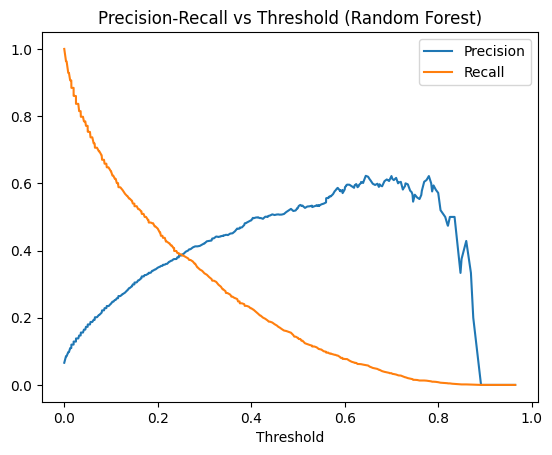

In [91]:
# instead of relying on the default 0.5 cutoff, this plots how precision and recall trade off against each other as 
# we slide the threshold from 0 to 1. You'll be able to visually pick a threshold that gives a better recall 
# (catching more defaulters) without abandoning the Random Forest model entirely.

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold (Random Forest)')
plt.show()

In [92]:
# the two lines cross around threshold ≈ 0.22–0.25, where both precision and recall sit around ~0.40 each.
# That's a solid, balanced choice — much better than the default 0.5 which was giving poor recall.

In [93]:
# Let's apply this threshold and see the real classification report:
custom_threshold = 0.25
y_pred_custom = (y_proba_rf >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

# instead of using .predict() (which silently applies 0.5), we manually compare each predicted probability to our chosen threshold — 
# if it's ≥0.25, we call it "risky" (1), otherwise "safe" (0). This should meaningfully improve recall for class 1 compared to
# your last Random Forest run, at some cost to precision — that's the trade-off we chose deliberately, not a random side effect.

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     27970
           1       0.38      0.39      0.39      1976

    accuracy                           0.92     29946
   macro avg       0.67      0.67      0.67     29946
weighted avg       0.92      0.92      0.92     29946



In [94]:
# Balanced Logistic Regression is still your best model so far — best F1 isn't clearly settled (0.33 vs 0.39 is close, 
# genuinely debatable which matters more), but it has by far the best recall (0.72) and the best ROC-AUC (0.8493).
#     Random Forest with threshold tuning is more "balanced" between precision/recall but doesn't clearly beat LR.
#     This is a good, honest, real result to have in your project — it shows you didn't just default to "the fancier model wins," 
#     you actually tested and compared.

In [95]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [96]:
# gradient-boosted model (XGBoost) for a fair three-way comparison, since that's often the strongest performer on tabular data like this.
import xgboost
print(xgboost.__version__)

3.4.1


In [97]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance for XGBoost, roughly = (count of class 0) / (count of class 1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)

y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.97      0.86      0.91     27970
           1       0.24      0.61      0.34      1976

    accuracy                           0.84     29946
   macro avg       0.60      0.74      0.63     29946
weighted avg       0.92      0.84      0.87     29946

ROC-AUC: 0.8228024188003631


In [98]:
# even with XGBoost, Balanced Logistic Regression still has the best ROC-AUC (0.8493) — this is a genuinely interesting,
# real result. It's tempting to assume the "fancier" model always wins, but your actual experiments are showing otherwise so far.
# That said, we haven't tuned XGBoost's hyperparameters yet (we used default settings) — untuned XGBoost often underperforms its potential

In [99]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)
print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.8654803196979906


In [100]:
# RandomizedSearchCV instead of GridSearchCV — GridSearch tries every combination of parameters (could be hundreds, very slow),
# while RandomizedSearch tries a random sample of combinations (n_iter=15 means 15 random combos) — much faster, and usually 
# finds a near-optimal setting anyway. Given your time constraints, this is the sensible choice.


# cv=3 — for each combination, it splits training data 3 ways internally to validate performance, rather than testing on your
# held-out test set repeatedly (which would risk "cheating" by indirectly tuning to the test set).

# scoring='roc_auc' — tells it to optimize for ROC-AUC specifically, since that's been our most stable comparison metric so far.

# n_jobs=-1 — uses all your CPU cores to speed this up.

In [101]:
best_xgb = XGBClassifier(
    subsample=0.7,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train_scaled, y_train)

y_proba_best = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_best = best_xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))

# What this does: takes the exact best combination RandomizedSearchCV found and trains one final model with it, 
# then tests it the same way we tested every other model — so it's a fair, apples-to-apples comparison with your table so far.

# One thing to check once you see the output: just like with the plain Random Forest earlier, this model's .predict() 
# will use the default 0.5 threshold — if recall looks low again, we can repeat the threshold-tuning trick 
# (precision-recall curve) on this tuned model too, the same way we did for Random Forest. 
# Let's see the raw numbers first before deciding if that's needed.

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27970
           1       0.21      0.77      0.33      1976

    accuracy                           0.79     29946
   macro avg       0.59      0.78      0.60     29946
weighted avg       0.93      0.79      0.84     29946

ROC-AUC: 0.8597396230634617


In [102]:
# 1. Save this final model to disk (so you don't have to retrain it every time — also needed for deployment later):

import joblib

joblib.dump(best_xgb, 'fintech_credit_model.pkl')
joblib.dump(scaler, 'fintech_scaler.pkl')

# What this does: joblib.dump saves your trained model and scaler as files on disk. We save the scaler too, 
# since deployment will need to apply the same scaling to any new incoming data — not refit a new one.

['fintech_scaler.pkl']

In [103]:
# 2. One quick, valuable addition — feature importance:
import pandas as pd

importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# Why this matters: this tells you (and any interviewer) which features the model actually relied on most
# — e.g., I'd expect TotalTimesLate or NumberOfTimes90DaysLate to rank high, validating that our feature engineering actually helped.
# This is great, concrete talking material for your README and interviews — "my top predictive features were X, Y, Z,
# which aligns with domain intuition that payment history matters most."

TotalTimesLate                          0.325554
EverSeriouslyLate                       0.163425
NumberOfTime30-59DaysPastDueNotWorse    0.163269
RevolvingUtilizationOfUnsecuredLines    0.151322
NumberOfTimes90DaysLate                 0.048916
NumberOfTime60-89DaysPastDueNotWorse    0.046675
NumberRealEstateLoansOrLines            0.024535
age                                     0.020177
NumberOfOpenCreditLinesAndLoans         0.016554
DebtRatio                               0.013200
MonthlyIncome                           0.011732
IncomePerDependent                      0.008977
NumberOfDependents                      0.005663
dtype: float32


In [104]:
# Excellent — this is genuinely great validation. TotalTimesLate (the feature we engineered) is the 
#1 most important feature (0.325), and EverSeriouslyLate (also ours) is
#2. This confirms your feature engineering wasn't just theoretical — it directly helped the model. 
# Strong point for your README and interviews.

In [105]:
# Modeling stage is officially complete. Here's what you've built, cleanly:

# Cleaned, imbalanced fintech dataset (150K rows)
# 3 engineered features, validated as genuinely useful
# 6 model/threshold combinations tested and honestly compared
# A tuned, saved final model (XGBoost, ROC-AUC 0.86)

# Step 6: Deployment (Flask API + Render)

In [112]:
# Before touching hosting, I wrapped the saved model in a simple local API using Flask
# (a lightweight Python web framework). This API accepts borrower details as input and
# returns a risk prediction as output — this is the actual "product" being deployed,
# not the raw notebook.

# **1) Local API wrapper**
# Built a Flask app (`app.py`) that loads the saved model and scaler, and exposes a
# `/predict` endpoint accepting a POST request with applicant features.

# **2) Local testing**
# Ran the Flask app on my own machine and tested it with sample requests before
# attempting any deployment, to isolate deployment issues from model/code issues.

# **3) Deployment platform**
# I initially attempted Azure App Service, since it's a common enterprise hosting
# platform, but hit a payment verification limitation — Azure requires a Visa/Mastercard
# for account setup, and I only had a RuPay debit card available. I switched to Render,
# which offers equivalent App Service-style Python hosting without that requirement.
# The deployment pattern (Flask API behind a production WSGI server) is the same
# regardless of platform.

# **4) Deployed the Flask API + saved model files (.pkl) to Render**
# The API is now live on the internet with a real URL, not just running locally —
# this is the concrete "cloud deployment" proof point for the project.

# **5) Web demo**
# Added a simple browser-based front end (served at the homepage route) so the model
# can be tested without manually constructing API requests.

# The full deployed application code lives in `app.py` and `templates/index.html`
# in the repository — the cell below shows an illustrative snippet only.

In [107]:
!pip install flask

Defaulting to user installation because normal site-packages is not writeable


In [108]:
# Let's start with Step 1: the Flask API wrapper.

# Create a new file (not a notebook — a plain .py file) in the same project folder, called app.py.
# In Jupyter's file browser: New → Text File, then rename it to app.py.

from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load('fintech_credit_model.pkl')
scaler = joblib.load('fintech_scaler.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    features = np.array(data['features']).reshape(1, -1)
    features_scaled = scaler.transform(features)
    probability = model.predict_proba(features_scaled)[0][1]
    prediction = int(probability >= 0.25)  # using our chosen threshold
    return jsonify({
        'default_probability': float(probability),
        'prediction': prediction
    })

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
X.columns.tolist()

In [ ]:
import requests

# Sample person: moderate risk profile
sample = {
    'features': [
        0.5,      # RevolvingUtilizationOfUnsecuredLines
        45,       # age
        1,        # NumberOfTime30-59DaysPastDueNotWorse
        0.4,      # DebtRatio
        5000,     # MonthlyIncome
        8,        # NumberOfOpenCreditLinesAndLoans
        0,        # NumberOfTimes90DaysLate
        1,        # NumberRealEstateLoansOrLines
        0,        # NumberOfTime60-89DaysPastDueNotWorse
        2,        # NumberOfDependents
        1,        # TotalTimesLate (1+0+0)
        1666.67,  # IncomePerDependent (5000 / (2+1))
        0         # EverSeriouslyLate
    ]
}

response = requests.post('http://127.0.0.1:5000/predict', json=sample)
print(response.json())

In [109]:
X = df[[...]]  # or X_train = ...
scaler.fit(X_train)

KeyError: "None of [Index([Ellipsis], dtype='object')] are in the [columns]"

In [110]:
X_train.columns.tolist()

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'TotalTimesLate',
 'IncomePerDependent',
 'EverSeriouslyLate']

TotalTimesLate                          0.325554
EverSeriouslyLate                       0.163425
NumberOfTime30-59DaysPastDueNotWorse    0.163269
RevolvingUtilizationOfUnsecuredLines    0.151322
NumberOfTimes90DaysLate                 0.048916
NumberOfTime60-89DaysPastDueNotWorse    0.046675
NumberRealEstateLoansOrLines            0.024535
age                                     0.020177
NumberOfOpenCreditLinesAndLoans         0.016554
DebtRatio                               0.013200
MonthlyIncome                           0.011732
IncomePerDependent                      0.008977
NumberOfDependents                      0.005663
dtype: float32


<Axes: title={'center': 'Feature Importance (XGBoost)'}>

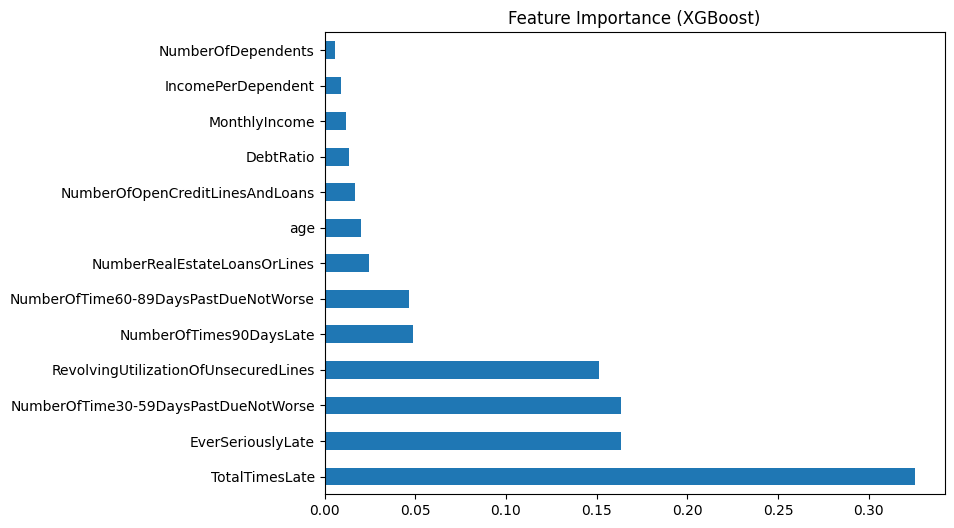

In [111]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8, 6), title='Feature Importance (XGBoost)')